In [1]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

zip_path = "/content/drive/MyDrive/dog-breed-120.zip"

In [3]:
import zipfile
import os

extract_path = "/content/dog_breed_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print("Location:", extract_path)

Dataset extracted successfully!
Location: /content/dog_breed_dataset


Check directories

In [4]:
dataset_dir = "/content/dog_breed_dataset/Dogs class"

In [5]:
import os

dataset_dir = "/content/dog_breed_dataset/Dogs class"

classes = sorted(os.listdir(dataset_dir))

print("Number of classes:", len(classes))
print("\nFirst 10 classes:")
print(classes[:10])

Number of classes: 122

First 10 classes:
['Untitled Folder', 'description.txt', 'n02085620-Chihuahua', 'n02085782-Japanese_spaniel', 'n02085936-Maltese_dog', 'n02086079-Pekinese', 'n02086240-Shih-Tzu', 'n02086646-Blenheim_spaniel', 'n02086910-papillon', 'n02087046-toy_terrier']


In [6]:
!pip install -q tensorflow matplotlib seaborn scikit-learn pandas numpy pillow

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Count images

In [8]:
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

# Get only folders containing images
classes = []

for cls in os.listdir(dataset_dir):
    class_path = os.path.join(dataset_dir, cls)

    # Check if it is a folder
    if os.path.isdir(class_path):

        # Check if folder contains at least one image
        has_image = any(
            file.lower().endswith(image_extensions)
            for file in os.listdir(class_path)
        )

        if has_image:
            classes.append(cls)

# Sort classes
classes = sorted(classes)

print("Number of valid classes:", len(classes))
print("First 10 classes:", classes[:10])


# Count images in each valid class
class_counts = {}

for cls in classes:
    class_path = os.path.join(dataset_dir, cls)

    count = sum(
        1
        for file in os.listdir(class_path)
        if file.lower().endswith(image_extensions)
    )

    class_counts[cls] = count


# Create DataFrame
class_counts_df = pd.DataFrame(
    list(class_counts.items()),
    columns=["Breed", "Image_Count"]
)

class_counts_df.head()

Number of valid classes: 120
First 10 classes: ['n02085620-Chihuahua', 'n02085782-Japanese_spaniel', 'n02085936-Maltese_dog', 'n02086079-Pekinese', 'n02086240-Shih-Tzu', 'n02086646-Blenheim_spaniel', 'n02086910-papillon', 'n02087046-toy_terrier', 'n02087394-Rhodesian_ridgeback', 'n02088094-Afghan_hound']


,Breed,Image_Count
0,n02085620-Chihuahua,152
1,n02085782-Japanese_spaniel,185
2,n02085936-Maltese_dog,252
3,n02086079-Pekinese,149
4,n02086240-Shih-Tzu,214


Dataset statistics

In [9]:
print("Total images:", class_counts_df["Image_Count"].sum())
print("Number of breeds:", len(class_counts_df))
print("Minimum images:", class_counts_df["Image_Count"].min())
print("Maximum images:", class_counts_df["Image_Count"].max())
print("Average images:", class_counts_df["Image_Count"].mean())

Total images: 20580
Number of breeds: 120
Minimum images: 148
Maximum images: 252
Average images: 171.5


Check class distribution

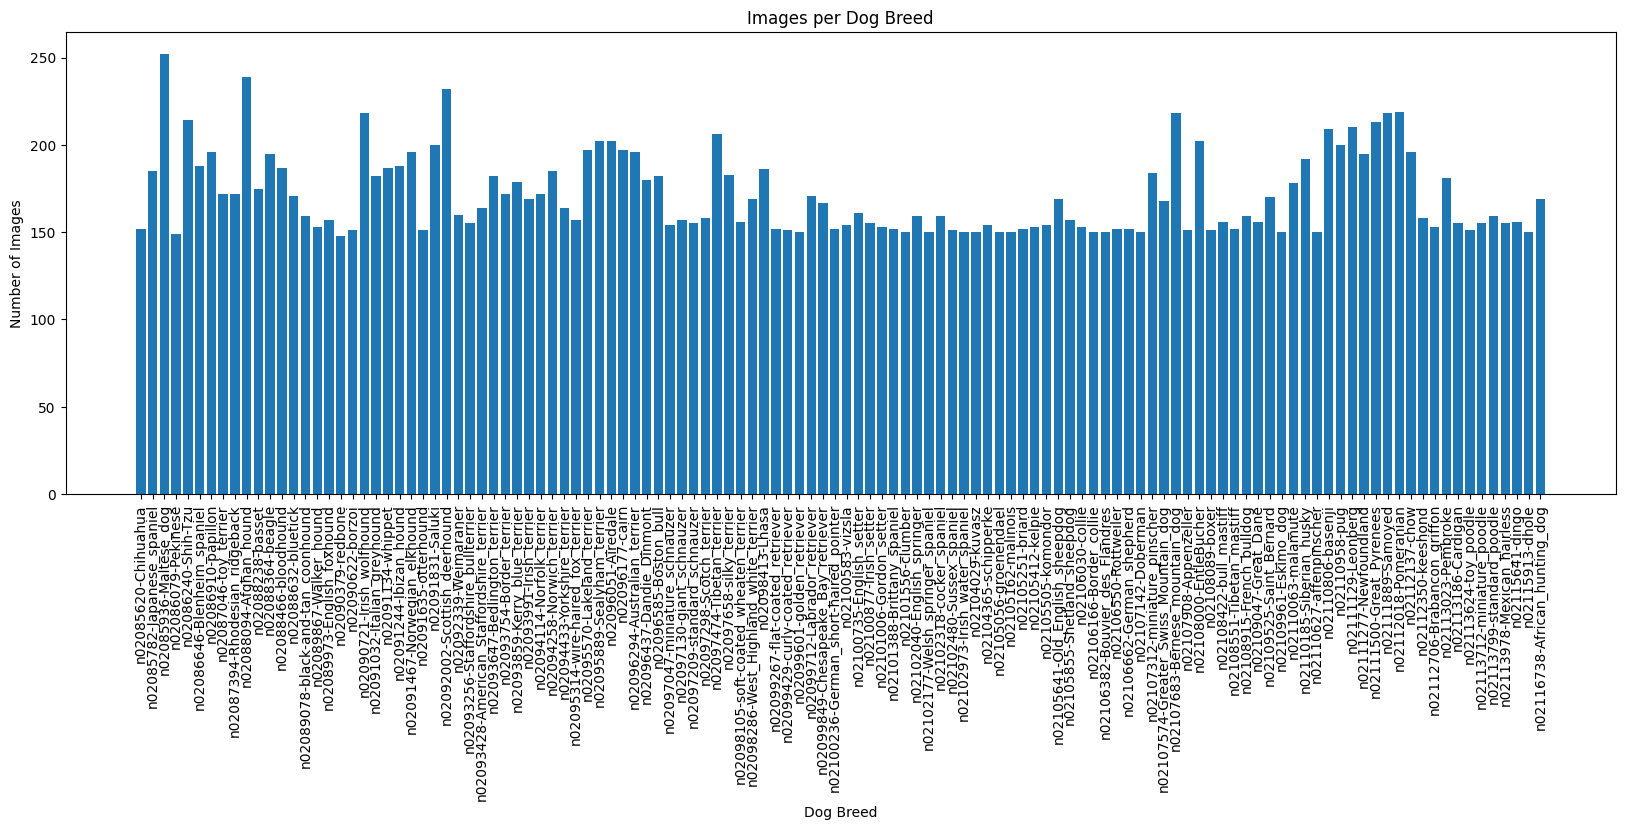

In [10]:
plt.figure(figsize=(20, 6))

plt.bar(
    class_counts_df["Breed"],
    class_counts_df["Image_Count"]
)

plt.xticks(rotation=90)
plt.xlabel("Dog Breed")
plt.ylabel("Number of Images")
plt.title("Images per Dog Breed")

plt.show()

Display random images

In [11]:
import random

plt.figure(figsize=(15, 10))

for i in range(12):
    breed = random.choice(classes)
    breed_path = os.path.join(dataset_dir, breed)

    images = [
        f for f in os.listdir(breed_path)
        if f.lower().endswith(image_extensions)
    ]

    image_name = random.choice(images)
    image_path = os.path.join(breed_path, image_name)

    image = Image.open(image_path)

    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title(breed)
    plt.axis("off")

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

Check image sizes

In [12]:
sizes = []

for cls in classes:
    class_path = os.path.join(dataset_dir, cls)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(image_extensions)
    ]

    for image_name in images[:20]:
        image_path = os.path.join(class_path, image_name)

        try:
            with Image.open(image_path) as img:
                sizes.append(img.size)
        except:
            pass

sizes_df = pd.DataFrame(sizes, columns=["Width", "Height"])

sizes_df.describe()

,Width,Height
count,2400.00000,2400.000000
mean,444.12750,385.046250
std,138.80577,117.724064
min,112.00000,120.000000
25%,360.00000,333.000000
50%,500.00000,375.000000
75%,500.00000,445.250000
max,2272.00000,1704.000000


Check corrupted images

In [13]:
corrupted_images = []

for cls in classes:
    class_path = os.path.join(dataset_dir, cls)

    for image_name in os.listdir(class_path):

        if not image_name.lower().endswith(image_extensions):
            continue

        image_path = os.path.join(class_path, image_name)

        try:
            with Image.open(image_path) as img:
                img.verify()

        except Exception:
            corrupted_images.append(image_path)

print("Corrupted images:", len(corrupted_images))

if corrupted_images:
    print("\nExamples:")
    for path in corrupted_images[:10]:
        print(path)

Corrupted images: 0


In [14]:
total_images = class_counts_df["Image_Count"].sum()

print("Total images:", total_images)
print("Total classes:", len(class_counts_df))

Total images: 20580
Total classes: 120


In [15]:
dataset_dir

'/content/dog_breed_dataset/Dogs class'

Now we'll create a DataFrame containing every image and its breed.

In [16]:
import os
import pandas as pd

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

data = []

for cls in classes:
    class_path = os.path.join(dataset_dir, cls)

    for file in os.listdir(class_path):

        if file.lower().endswith(image_extensions):

            image_path = os.path.join(class_path, file)

            data.append({
                "image_path": image_path,
                "breed": cls
            })

df = pd.DataFrame(data)

print("Total images:", len(df))
print("Total classes:", df["breed"].nunique())

df.head()

Total images: 20580
Total classes: 120


,image_path,breed
0,/content/dog_breed_dataset/Dogs class/n0208562...,n02085620-Chihuahua
1,/content/dog_breed_dataset/Dogs class/n0208562...,n02085620-Chihuahua
2,/content/dog_breed_dataset/Dogs class/n0208562...,n02085620-Chihuahua
3,/content/dog_breed_dataset/Dogs class/n0208562...,n02085620-Chihuahua
4,/content/dog_breed_dataset/Dogs class/n0208562...,n02085620-Chihuahua


Create integer labels

In [17]:
classes = sorted(df["breed"].unique())

class_to_index = {
    breed: index
    for index, breed in enumerate(classes)
}

index_to_class = {
    index: breed
    for breed, index in class_to_index.items()
}

Verify labels

In [18]:
print("Number of classes:", len(classes))

print("\nFirst 10 mappings:")
for i in range(10):
    print(i, "→", index_to_class[i])

Number of classes: 120

First 10 mappings:
0 → n02085620-Chihuahua
1 → n02085782-Japanese_spaniel
2 → n02085936-Maltese_dog
3 → n02086079-Pekinese
4 → n02086240-Shih-Tzu
5 → n02086646-Blenheim_spaniel
6 → n02086910-papillon
7 → n02087046-toy_terrier
8 → n02087394-Rhodesian_ridgeback
9 → n02088094-Afghan_hound


In [19]:
df["label"] = df["breed"].map(class_to_index)

In [20]:
df.head()

,image_path,breed,label
0,/content/dog_breed_dataset/Dogs class/n0208562...,n02085620-Chihuahua,0
1,/content/dog_breed_dataset/Dogs class/n0208562...,n02085620-Chihuahua,0
2,/content/dog_breed_dataset/Dogs class/n0208562...,n02085620-Chihuahua,0
3,/content/dog_breed_dataset/Dogs class/n0208562...,n02085620-Chihuahua,0
4,/content/dog_breed_dataset/Dogs class/n0208562...,n02085620-Chihuahua,0


In [21]:
print("Minimum label:", df["label"].min())
print("Maximum label:", df["label"].max())
print("Unique labels:", df["label"].nunique())

Minimum label: 0
Maximum label: 119
Unique labels: 120


Train / Validation / Test split

In [22]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["breed"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["breed"],
    random_state=42
)

In [23]:
print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Testing:", len(test_df))

Training: 14406
Validation: 3087
Testing: 3087


Verify all 120 classes


In [24]:
print("Train classes:", train_df["breed"].nunique())
print("Validation classes:", val_df["breed"].nunique())
print("Test classes:", test_df["breed"].nunique())

Train classes: 120
Validation classes: 120
Test classes: 120


Create TensorFlow datasets

In [25]:
SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 120
EPOCHS = 30

tf.random.set_seed(SEED)
np.random.seed(SEED)

In [26]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        train_df["image_path"].values,
        train_df["label"].values
    )
)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (
        val_df["image_path"].values,
        val_df["label"].values
    )
)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (
        test_df["image_path"].values,
        test_df["label"].values
    )
)

Image loading function


In [27]:
def load_image(image_path, label):

    # Read image file
    image = tf.io.read_file(image_path)

    # Decode image
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    # Resize
    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    # Convert to float32
    image = tf.cast(
        image,
        tf.float32
    )

    return image, label

Apply the function

In [28]:
train_dataset = train_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_dataset = val_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_dataset = test_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

Batch + Shuffle + Prefetch

- **Batch:** Divides the dataset into smaller groups of images that are processed together during training. For example, `batch_size=32` means the model processes 32 images at a time.

- **Shuffle:** Randomly changes the order of training images before/during training. This prevents the model from learning patterns based on the original order of the dataset.

- **Prefetch:** Loads and prepares the next batch of images while the model is training on the current batch. This reduces waiting time and makes training faster and more efficient.

**In short:**  
`Shuffle → Mix the images`  
`Batch → Group the images`  
`Prefetch → Prepare the next batch in advance`

In [29]:
train_dataset = train_dataset.shuffle(
    buffer_size=len(train_df),
    seed=42
).batch(BATCH_SIZE)

val_dataset = val_dataset.batch(BATCH_SIZE)  #optional

test_dataset = test_dataset.batch(BATCH_SIZE)  #optional

In [ ]:
train_dataset = train_dataset.prefetch(
    tf.data.AUTOTUNE
)

val_dataset = val_dataset.prefetch(
    tf.data.AUTOTUNE
)

test_dataset = test_dataset.prefetch(
    tf.data.AUTOTUNE
)

Verify everything

In [31]:
images, labels = next(iter(train_dataset))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

print("First label:", labels[0].numpy())
print("First breed:", index_to_class[labels[0].numpy()])

Images shape: (32, 224, 224, 3)
Labels shape: (32,)
First label: 110
First breed: n02112706-Brabancon_griffon


Display images

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for i in range(9):

    plt.subplot(3, 3, i + 1)

    plt.imshow(
        images[i].numpy().astype("uint8")
    )

    label = labels[i].numpy()

    plt.title(index_to_class[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

Data Augmentation

In [ ]:
data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip(
        "horizontal"
    ),

    tf.keras.layers.RandomRotation(
        0.10
    ),

    tf.keras.layers.RandomZoom(
        0.10
    ),

    tf.keras.layers.RandomTranslation(
        height_factor=0.10,
        width_factor=0.10
    ),

    tf.keras.layers.RandomContrast(
        0.10
    )

], name="data_augmentation")

Build CNN From Scratch

In [ ]:
cnn_model = tf.keras.Sequential([

    tf.keras.layers.Input(
        shape=(224, 224, 3)
    ),

    # Data Augmentation
    data_augmentation,

    # Normalization
    tf.keras.layers.Rescaling(
        1.0 / 255
    ),

    # Block 1
    tf.keras.layers.Conv2D(
        32,
        (3, 3),
        padding="same",
        activation="relu"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),

    # Block 2
    tf.keras.layers.Conv2D(
        64,
        (3, 3),
        padding="same",
        activation="relu"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),

    # Block 3
    tf.keras.layers.Conv2D(
        128,
        (3, 3),
        padding="same",
        activation="relu"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),

    # Block 4
    tf.keras.layers.Conv2D(
        256,
        (3, 3),
        padding="same",
        activation="relu"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),

    # Block 5
    tf.keras.layers.Conv2D(
        512,
        (3, 3),
        padding="same",
        activation="relu"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),

    # Feature extraction
    tf.keras.layers.GlobalAveragePooling2D(),

    # Classifier
    tf.keras.layers.Dense(
        512,
        activation="relu"
    ),

    tf.keras.layers.Dropout(
        0.5
    ),

    # Output
    tf.keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

cnn_model.summary()

In [ ]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]
)

In [ ]:
callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(             #ReduceLROnPlateau is a Keras callback that automatically reduces the learning rate when the model stops improving.
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "best_cnn_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]

In [ ]:
history = cnn_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks
)

Plot Loss

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

Evaluate on Test Set

In [ ]:
test_loss, test_accuracy = cnn_model.evaluate(
    test_dataset,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

Generate Predictions

In [ ]:
y_true = []
y_pred = []

for images, labels in test_dataset:

    predictions = cnn_model.predict(
        images,
        verbose=0
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(
        labels.numpy()
    )

    y_pred.extend(
        predicted_labels
    )

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("True labels:", y_true.shape)
print("Predicted labels:", y_pred.shape)

Classification Report

In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=classes,
        zero_division=0
    )
)

Confusion Matrix

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(20, 20))

plt.imshow(cm)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("CNN Confusion Matrix")

plt.colorbar()

plt.show()